<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="https://www.upct.es/contenido/universidad/galeria/identidad-2021/logos/logos-upct/marca-upct/marca-principal/horizontal/azul.png" alt="UPCT" style="height:145px; width:auto;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="https://www.um.es/documents/1073494/42130150/LogosimboloUMU-positivo.png" alt="UMU" style="height:200px; width:auto;">
</div>

# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 4: Autocodificadores
### **Sesión 3/3: Autocodificadores variacionales**

**Autores**: Juan Morales Sánchez, Antonio Martínez Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya
___

### Objetivos

- Diseño de un *autoencoder* variacional.
- Comprender el aprendizaje probabilístico y las diferencias respecto a un *autoencoder* convencional
- Comprender el concepto de reparametrización y muestreo del espacio latente.
- Aplicación a la generación de imágenes.

### Contenidos
- [El dataset CelebA](#dataset)
- [*Autoencoder* variacional](#VAE)
- [Ejercicios](#ejercicios)

### Requisitos 
<a class='anchor' id='requisitos'></a>

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Scipy](https://pypi.org/project/scipy/) (computación científica)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (*Machine Learning*)
- [Scikit-image](https://pypi.org/project/scikit-image/) (*Image Processing*)
- [Matplotlib](https://pypi.org/project/matplotlib/) y [Seaborn](https://pypi.org/project/seaborn/) (visualización de datos)
- [Tensorflow](https://www.tensorflow.org/) 2.x que incluye a [Keras](https://www.tensorflow.org/guide/keras) 2.x (*Deep Learning*)


<a class='anchor' id='dataset'></a>

## El dataset CelebA

En esta sesión de prácticas emplearemos también el dataset [50k Celeba Dataset 64x64](https://www.kaggle.com/datasets/therealcyberlord/50k-celeba-dataset-64x64).

<a class='anchor' id='VAE'></a>

## *Autoencoder* variacional

Un *autoencoder* variacional (VAE) es un tipo específico de *autoencoder* generativo. Mientras que un autoencoder clásico se centra en aprender una representación compacta (o codificación) para reconstruir la entrada, un autoencoder generativo, como el VAE, va un paso más allá: aprende una distribución probabilística en el espacio latente que permite generar nuevas muestras.

<div style="display:flex; justify-content:space-around; align-items:center; padding:5px solid #333333;">
    <img src="imgs/VAE.png" style="height:300px; width:auto">
</div>

Podemos resumir las principales diferencias de un VAE respecto a un *autoencoder* convencional en:

- **Aprendizaje probabilístico:**  
  En un VAE se modela la codificación como una distribución, habitualmente gaussiana de media $\mu$ y varianza $\sigma$, lo que permite tomar muestras de dicha distribución en el espacio latente $z$ y generar datos nuevos. Esto contrasta con un *autoencoder* tradicional, que produce una representación determinista.

- **Pérdida combinada:**  
  Los VAE añaden a la función de pérdida no solo el error de reconstrucción, sino también un término de divergencia KL (Kullback-Leibler) que regulariza la distribución latente $z$ para que se aproxime a la distribución de probabilidad predeterminada. Esto facilita la generación de muestras coherentes y continuas en el espacio latente.

- **Generación de nuevos datos:**  
  Mediante al muestreo en el espacio latente los VAE pueden generar nuevas datos que son similares a los datos de entrenamiento, convirtiéndolos en modelos generativos efectivos.

  A continuación se muestra un ejemplo de resultados de generación de imágenes de caras mediante VAE a partir del dataset [50k Celeba Dataset 64x64](https://www.kaggle.com/datasets/therealcyberlord/50k-celeba-dataset-64x64): 

<div style="display:flex; justify-content:space-around; align-items:center; padding:5px solid #333333;">
    <img src="imgs/generated_images.png" style="height:1000px; width:auto">
</div>

<a class='anchor' id='ejercicios'></a>

## Ejercicios

**E1:** Partiendo del trabajo de la sesión anterior, adapte un *autoencoder* convolucional de 3 niveles de profundidad, utilizando capas convolucionales 2D de 16, 32 y 64 mapas de características, más el nivel correspondiente al espacio latente (dimensión 64), para que se comporte como un *autoencoder* variacional. Para ello se debe atender a los aspectos puntualizados en el [apartado previo](#VAE) y [personalizar el modelo](https://www.tensorflow.org/guide/keras/making_new_layers_and_models_via_subclassing) para: 1) incorporar la reparametrización y muestro del espacio latente, forzando su estadística a una distribución normal (se requieren capas adicionales totalmente conectadas para enlazar con el nuevo espacio latente reparametrizado), y 2) implementación de la pérdida combinada (suma de la pérdida estándar del *autoencoder* con la pérdida de divergencia KL).

In [8]:
# Importar librerías necesarias
import os
import numpy as np
from tensorflow.keras.utils import get_file
from tensorflow.image import rgb_to_grayscale
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Descargar el dataset
dataset_url = "https://www.kaggle.com/api/v1/datasets/download/therealcyberlord/50k-celeba-dataset-64x64"

dataset_path = get_file(origin=dataset_url, extract=True)

base_dir = os.path.join(
    os.path.dirname(dataset_path), "50k-celeba-dataset-64x64", "50k"
)
try:
    os.listdir(base_dir)
except Exception:
    base_dir = os.path.join(os.path.dirname(dataset_path), "50k")

print(f"Leyendo imágenes desde {base_dir:s}")

# Preparar listas para imágenes
NUMBER_OF_IMAGES = 10000  # <= 50000
IMAGE_DIM = (64, 64)

images = np.empty((NUMBER_OF_IMAGES, *IMAGE_DIM, 3))
images_gray = np.empty((NUMBER_OF_IMAGES, *IMAGE_DIM, 1))
for i, img_file in enumerate(os.listdir(base_dir)):
    if (i > 0) and (i % 1000 == 0):
        print(f"Cargadas {i:d} imágenes...")
    if i == NUMBER_OF_IMAGES:
        break
    img_path = os.path.join(base_dir, img_file)
    img = load_img(
        img_path, target_size=IMAGE_DIM, color_mode="rgb"
    )  # Redimensionar imágenes
    images[i] = img_to_array(img) / 255.0  # Normalizar a [0, 1]
    images_gray[i] = rgb_to_grayscale(images[i])

Leyendo imágenes desde /home/pyros05/.keras/datasets/50k-celeba-dataset-64x64/50k
Cargadas 1000 imágenes...
Cargadas 2000 imágenes...
Cargadas 3000 imágenes...
Cargadas 4000 imágenes...
Cargadas 5000 imágenes...
Cargadas 6000 imágenes...
Cargadas 7000 imágenes...
Cargadas 8000 imágenes...
Cargadas 9000 imágenes...
Cargadas 10000 imágenes...


In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# 1. Capa de muestreo (Reparametrization trick)
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

latent_dim = 64

# 2. Encoder Conv2D (16 -> 32 -> 64)
encoder_inputs = keras.Input(shape=(64, 64, 3))
x = layers.Conv2D(16, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# 3. Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(8 * 8 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((8, 8, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(16, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

# 4. VAE Personalizado
class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight=1.0, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.kl_weight = kl_weight
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            # Pérdida de reconstrucción (binary crossentropy)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            # Divergencia KL
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            
            # Pérdida combinada (con ponderación KL)
            total_loss = reconstruction_loss + (self.kl_weight * kl_loss)
            
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

**E2:** Entrene el modelo con las imágenes de caras en color, y genere conjuntos de nuevas imágenes, similares a los mostrados en el [apartado previo](#VAE). Comente las diferencias en cuando a prestaciones con un *autoencoder* convolucional: calidad de la reconstrucción conseguida, número de parámetros necesarios en el modelo, tiempo de entrenamiento, etc. Tenga en cuenta que dado que el objetivo fundamental en este caso es generar imágenes y no reconstruirlas, los conjuntos de validación y test son prescindibles, y la parada anticipada puede realizarse directamente sobre el conjunto de entrenamiento (el sobreajuste puede mejorar la capacidad de generación de imágenes).

Epoch 1/30


I0000 00:00:1777475158.284076   96121 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_306358__.17


76/79 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - kl_loss: 2.9150 - loss: 2776.1334 - reconstruction_loss: 2773.2185

I0000 00:00:1777475161.010563   96123 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_306358__.17


79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - kl_loss: 7.7155 - loss: 2711.0996 - reconstruction_loss: 2703.3848
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 16.6084 - loss: 2561.8633 - reconstruction_loss: 2545.2544
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 29.1126 - loss: 2445.9014 - reconstruction_loss: 2416.7893
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 33.7134 - loss: 2405.2551 - reconstruction_loss: 2371.5422
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 32.9201 - loss: 2392.1868 - reconstruction_loss: 2359.2664
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 32.1899 - loss: 2382.2773 - reconstruction_loss: 2350.0884
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 31.9492 - loss: 2377.3232 - reconstruction_loss: 2345.3743
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 30.7732 - loss: 2371.1196 - reconstruction_loss: 2340.3462
Epoch 9/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/s

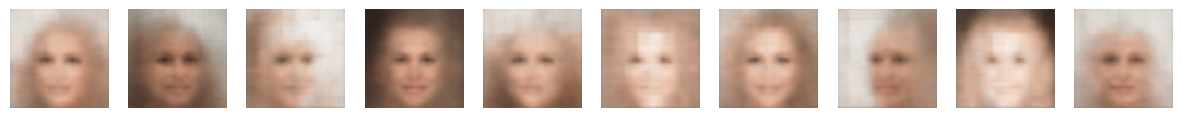

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

# Entrenamiento
early_stopping = EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)

history = vae.fit(images, epochs=30, batch_size=128, callbacks=[early_stopping])

# Generación de imágenes nuevas aleatorias desde el espacio latente
def generar_imagenes(decoder, n=5):
    # Toma valores de la distribución normal N(0,1)
    z_sample = np.random.normal(size=(n, latent_dim))
    imagenes_generadas = decoder.predict(z_sample)

    fig, axes = plt.subplots(1, n, figsize=(15, 3)) 
    for i in range(n):
        axes[i].imshow(imagenes_generadas[i])
        axes[i].axis('off')
    plt.show()

generar_imagenes(vae.decoder, n=10)

**E3:** Evalúe la influencia sobre las prestaciones analizadas en el ejercicio E2 de:
- El aumento de la dimensión del espacio latente (máximo 1024).
- La ponderación de las pérdidas en la implementación de la suma de la pérdida combinada (desde 1 a 1, hasta un máximo de 10 a 1, orientativamente).

Epoch 1/30


I0000 00:00:1777475187.763110   96120 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_324444__.17


74/79 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - kl_loss: 0.0288 - loss: 2802.3236 - reconstruction_loss: 2802.0357

I0000 00:00:1777475190.965816   96119 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_324444__.17


79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - kl_loss: 0.0433 - loss: 2778.6553 - reconstruction_loss: 2778.2217
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 0.1628 - loss: 2743.7000 - reconstruction_loss: 2742.0718
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 0.3141 - loss: 2712.5071 - reconstruction_loss: 2709.3655
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 0.2281 - loss: 2701.1682 - reconstruction_loss: 2698.8872
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 0.1362 - loss: 2696.5178 - reconstruction_loss: 2695.1550
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 0.0746 - loss: 2694.1316 - reconstruction_loss: 2693.3853
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 0.0446 - loss: 2692.4851 - reconstruction_loss: 2692.0396
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 0.0274 - loss: 2690.3667 - reconstruction_loss: 2690.0925
Epoch 9/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step 

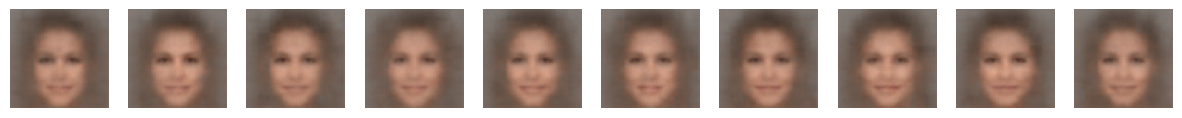

In [11]:
latent_dim_e3 = 1024

# 2. Encoder Conv2D E3
encoder_inputs_e3 = keras.Input(shape=(64, 64, 3))
x = layers.Conv2D(16, 3, activation="relu", strides=2, padding="same")(encoder_inputs_e3)
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
z_mean_e3 = layers.Dense(latent_dim_e3, name="z_mean")(x)
z_log_var_e3 = layers.Dense(latent_dim_e3, name="z_log_var")(x)
z_e3 = Sampling()([z_mean_e3, z_log_var_e3])  # Sampling se definió en E1
encoder_e3 = keras.Model(encoder_inputs_e3, [z_mean_e3, z_log_var_e3, z_e3], name="encoder_e3")

# 3. Decoder E3
latent_inputs_e3 = keras.Input(shape=(latent_dim_e3,))
x = layers.Dense(8 * 8 * 64, activation="relu")(latent_inputs_e3)
x = layers.Reshape((8, 8, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(16, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs_e3 = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder_e3 = keras.Model(latent_inputs_e3, decoder_outputs_e3, name="decoder_e3")

# Instanciar el VAE definido en el apartado anterior, con el nuevo peso KL
vae_e3 = VAE(encoder_e3, decoder_e3, kl_weight=10.0)
vae_e3.compile(optimizer=keras.optimizers.Adam())

# Entrenamiento
early_stopping = EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)
history_e3 = vae_e3.fit(images, epochs=30, batch_size=128, callbacks=[early_stopping])

# Al llamar a la función, le pasamos también la nueva dimensión para evitar el error de variables globales
def generar_imagenes_dinamico(decoder_model, dim_latente, n=5):
    z_sample = np.random.normal(size=(n, dim_latente))
    imagenes_generadas = decoder_model.predict(z_sample, verbose=0)
    fig, axes = plt.subplots(1, n, figsize=(15, 3)) 
    for i in range(n):
        axes[i].imshow(imagenes_generadas[i])
        axes[i].axis('off')
    plt.show()

generar_imagenes_dinamico(vae_e3.decoder, latent_dim_e3, n=10)

**E4:** Volviendo a la configuración del ejercicio E2. codifique todas las imágenes de entrenamiento en el espacio latente, y aplique a las codificaciones resultantes una reducción de dimensionalidad a 2 dimensiones con el [algoritmo PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), y compruebe mediante representación visual de dichas componentes si la estadística de dicho espacio se ajusta la predeterminada.

I0000 00:00:1777475218.098272   96120 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_338168__.1


154/313 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step

I0000 00:00:1777475218.524652   96120 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_concatenate_fusion', 8 bytes spill stores, 8 bytes spill loads



294/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

I0000 00:00:1777475218.923633   96120 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_339533__.1


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


I0000 00:00:1777475219.350859   96120 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_concatenate_fusion', 8 bytes spill stores, 8 bytes spill loads



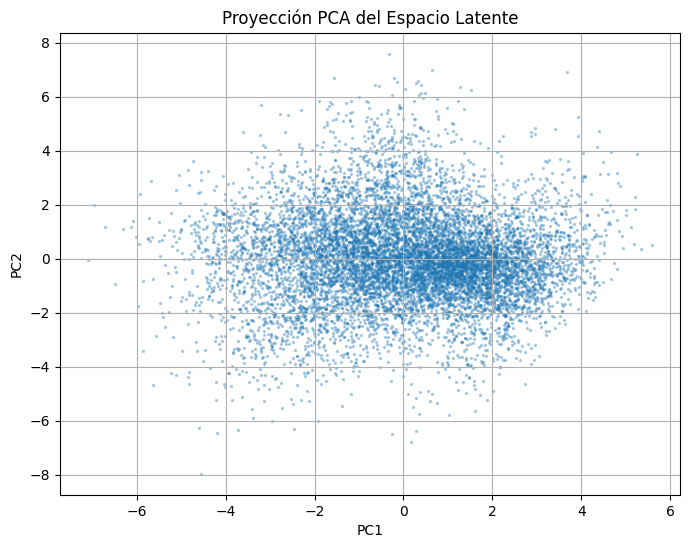

In [12]:
from sklearn.decomposition import PCA

# Extraemos solo las codificaciones medias (z_mean)
z_mean, _, _ = vae.encoder.predict(images)

pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_mean)

plt.figure(figsize=(8, 6))
plt.scatter(z_pca[:, 0], z_pca[:, 1], alpha=0.3, s=2)
plt.title("Proyección PCA del Espacio Latente")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

**E5:** Dadas las particularidades del conjunto de datos (imágenes de caras), resulta directo aplicar un aumento de datos trivial que duplique el tamaño del conjunto de entrenamiento, y que consiste en realizar un giro especular (horizontal) a cada una de las imágenes, y añadir dichas imágenes al conjunto inicial de entrenamiento. Implemente dicho aumento de datos y comente su influencia en la calidad de las imágenes generadas. En función de las posibilidades de cómputo, aumente también la cantidad de imágenes del conjunto de entrenamiento que se leen inicialmente del dataset [50k Celeba Dataset 64x64](https://www.kaggle.com/datasets/therealcyberlord/50k-celeba-dataset-64x64)

In [14]:
# Aumento de datos: giro especular
X_train_flipped = np.flip(images, axis=2) # axis=2 es el eje horizontal (H, W, C) -> voltear columnas
X_train_augmented = np.concatenate((images, X_train_flipped), axis=0).astype(np.float32)

print(f"Número total de imágenes tras Data Augmentation: {X_train_augmented.shape[0]}")

# Para evitar problemas de memoria en la GPU al pasar tensores muy grandes,
# creamos un tf.data.Dataset para gestionar la carga en lotes.
train_dataset = tf.data.Dataset.from_tensor_slices(X_train_augmented).batch(128).prefetch(tf.data.AUTOTUNE)

# Ahora re-entrenamos el VAE usando el dataset
vae.fit(train_dataset, epochs=30)

Número total de imágenes tras Data Augmentation: 20000


W0000 00:00:1777475292.595675   95915 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 937.50MiB (rounded to 983040000)requested by op _EagerConst
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1777475292.595713   95915 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1777475292.595714   95915 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 277, Chunks in use: 275. 69.2KiB allocated for chunks. 68.8KiB in use in bin. 14.4KiB client-requested in use in bin.
I0000 00:00:1777475292.595716   95915 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 15, Chunks in use: 12. 7.5KiB allocated for chunks. 6.0KiB in use in bin. 6.0KiB client-requested in use in bin.
I0000 00:00:1777475292.595718   95915 bfc_allocator.cc:1056] Bin (1024): 	Total Chunks: 22, Chunks in use: 22. 38.0Ki

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.